# Resident near-term incident risk (“at-risk girls”) — ML pipeline

**Porto Bella / IS 455** — Notebook sections follow the course lifecycle.  
**Working agreement:** Complete and review each step before running or filling the next.


---
## Step 1: Problem framing

### Part A — IS 455 / INTEX requirements *(read this first)*

**Context (one line):** **Porto Bella** (Italy) serves girls in safehouse care; **Giulia** and staff fear **girls falling through the cracks** when problems escalate unnoticed. This pipeline supports **prioritization**, not replacement of professional judgment.

---

#### 1. Business question

> **Given routine case records (counseling sessions, education, health, home visits, intervention plans, and prior incident history), which residents are most likely—in the next 30 calendar days—to have a new row in `incident_reports` where `severity` is High **or** `follow_up_required` is True, so Giulia’s team can prioritize supervision and follow-up?**

**Label (outcome) — draft, validate in Step 2–3:**
- **Positive:** ≥1 qualifying incident in the **30 days after** the snapshot date.  
- **Negative:** none in that window.  
- **Grain (draft):** preferably **resident-month** (features through end of month *m*, predict the next 30 days); fallback documented if data are too sparse.  
- **Features rule:** only data **knowable at snapshot time** (no future leakage).

---

#### 2. Success metrics *(how we judge the model later)*

| Metric | Role |
|--------|------|
| **ROC-AUC** | Can we rank “event within 30 days” higher than chance? |
| **Precision / recall** at a chosen cutoff | Match **staff capacity** (e.g. only *k* deep reviews per month). |
| **Confusion matrix** | **False negative** = missed escalation (costly). **False positive** = extra work / stigma risk — use neutral UI and human override. |
| **Simple baseline** | Beat an obvious rule (e.g. flag prior high-severity history only) or gains are not meaningful. |

---

#### 3. Model approach *(per IS 455: prediction vs explanation)*

| Approach | Purpose in this notebook |
|----------|-------------------------|
| **Predictive** *(primary)* | Maximize **out-of-sample** performance: probabilities or ranks for triage on held-out residents or time periods. |
| **Explanatory** *(required later)* | Separate **interpretable** model (e.g. logistic regression) for **associations** and the rubric’s *causal/relationship* discussion — **not** proof of causation. |

**Deployment (IS 455):** integrate scores or flags into the **web app** (e.g. admin dashboard / API) with language like **“Suggested case review”** or **“priority for follow-up this period.”** Not a substitute for statutory child-protection or clinical assessment.

---

### Part B — Textbook Ch. 1 *(optional context)*

This step matches **CRISP-DM Phase 1 — Business understanding**: clarify the problem, success criteria, and whether the project is feasible before heavy modeling. Ch. 1 also stresses **data availability**, **analytical feasibility** (our sample is small — we aim for a defensible, transparent model), **fitting the tool into workflows** (admin UI, existing records), and **iterating** if Step 2–3 show the label is unusable. *Predictive vs explanatory project types* (§1.9) are why we lead with **prediction** and add **explanation** second.


---
## Step 2: Data acquisition & preparation (Ch. 2–5, 7)

### Part A — Data understanding (Ch. 2–5)

This step creates the **modeling dataset** at the correct grain (**resident × month-end snapshot**) and verifies that we can support the business question using the provided tables.

#### Data sources (provided CSVs)

| Table | What we use it for |
|-------|---------------------|
| `residents` | Admission/closure dates for valid snapshots; `safehouse_id`; `initial_risk_level` (we avoid `current_risk_level` to reduce post-hoc leakage risk); static case category / subcategory flags |
| `incident_reports` | **Label:** qualifying incident in the next 30 days. **History features:** prior incidents on/before snapshot |
| `process_recordings` | Session frequency + concern/referral rates up to snapshot |
| `education_records` | Recent attendance/progress up to snapshot |
| `health_wellbeing_records` | Latest general health score up to snapshot |
| `home_visitations` | Visit counts and unfavorable/uncooperative rates up to snapshot |
| `intervention_plans` | Plan counts and share still Open/In Progress/On Hold up to snapshot |

#### Join + time logic (prevents leakage)

- **Join key:** `resident_id`.
- **Feature window:** rows with event date **`≤ snapshot_date`**.
- **Label window:** incidents with `incident_date` from the **day after** snapshot through **snapshot + 30 days** (snapshot day excluded).

#### Grain / rows

- **Grain:** one row per **resident × month-end snapshot** while the resident is in care.
- **Last snapshot rule:** the latest month-end such that we still have 30 days of incident data after it.

### Part B — Data preparation pipeline (Ch. 7)

We implement this as a **reproducible pipeline**, not one-off code:

1. `load_raw_tables(data_dir)` — load CSVs, parse dates, coerce boolean fields.
2. `build_resident_month_panel(raw)` — build the labeled panel + engineered features.
3. `fill_missing_feature_values(df)` — handle missing values from sparse history.
4. `run_preparation_pipeline()` — end-to-end function that returns `modeling_df`.

#### Cleaning / transformation choices

- **Booleans:** normalize `follow_up_required`, `resolved`, and resident flags (`sub_cat_*`, family flags).
- **Missing values:**
  - “Rates” become **0** when there is no history.
  - Continuous measures (e.g. recent attendance/progress, health score) are imputed with a **median** for this notebook (we will note the production caveat later in evaluation).


In [7]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

# If you run the notebook from ml-pipelines/, this finds ../lighthouse_csv_v7
REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == "ml-pipelines" else Path.cwd().resolve()
DATA_DIR = REPO_ROOT / "lighthouse_csv_v7"

RESIDENT_BOOL_COLS = {
    "is_pwd",
    "has_special_needs",
    "family_is_4ps",
    "family_solo_parent",
    "family_indigenous",
    "family_parent_pwd",
    "family_informal_settler",
}


def _coerce_bool_series(s: pd.Series) -> pd.Series:
    if s.dtype == bool:
        return s
    if s.dtype == object:
        m = {"True": True, "False": False, True: True, False: False}
        return s.map(lambda x: m.get(x, x))
    return s.astype(bool)


def load_raw_tables(data_dir: str | Path) -> dict[str, pd.DataFrame]:
    """Load all tables needed for the resident-month incident-risk panel."""
    data_dir = Path(data_dir)
    tables: dict[str, pd.DataFrame] = {}

    tables["residents"] = pd.read_csv(
        data_dir / "residents.csv",
        parse_dates=["date_of_birth", "date_of_admission", "date_closed", "date_enrolled", "created_at"],
    )
    tables["incident_reports"] = pd.read_csv(
        data_dir / "incident_reports.csv",
        parse_dates=["incident_date", "resolution_date"],
    )
    tables["process_recordings"] = pd.read_csv(
        data_dir / "process_recordings.csv",
        parse_dates=["session_date"],
    )
    tables["education_records"] = pd.read_csv(
        data_dir / "education_records.csv",
        parse_dates=["record_date"],
    )
    tables["health_wellbeing_records"] = pd.read_csv(
        data_dir / "health_wellbeing_records.csv",
        parse_dates=["record_date"],
    )
    tables["home_visitations"] = pd.read_csv(
        data_dir / "home_visitations.csv",
        parse_dates=["visit_date"],
    )
    tables["intervention_plans"] = pd.read_csv(
        data_dir / "intervention_plans.csv",
        parse_dates=["target_date", "case_conference_date", "created_at", "updated_at"],
    )

    for col in ("resolved", "follow_up_required"):
        if col in tables["incident_reports"].columns:
            tables["incident_reports"][col] = _coerce_bool_series(tables["incident_reports"][col])

    r = tables["residents"]
    for c in r.columns:
        if c.startswith("sub_cat_") or c in RESIDENT_BOOL_COLS:
            if r[c].dtype != bool:
                r[c] = _coerce_bool_series(r[c])

    return tables


def month_end_on_or_before(d: pd.Timestamp) -> pd.Timestamp:
    return pd.Timestamp(d).normalize().to_period("M").to_timestamp(how="end")


def qualifying_incident_mask(incidents: pd.DataFrame) -> pd.Series:
    sev = incidents["severity"].astype(str).str.strip()
    return (sev == "High") | (incidents["follow_up_required"] == True)


def build_resident_month_panel(raw: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """One row per resident × month-end snapshot; label = qualifying incident in next 30 days."""
    res = raw["residents"].copy()
    inc = raw["incident_reports"].copy()
    inc["_qualifying"] = qualifying_incident_mask(inc)

    data_max = inc["incident_date"].max()
    last_valid = data_max - pd.Timedelta(days=30)
    last_valid_me = pd.Timestamp(last_valid).to_period("M").to_timestamp(how="end")

    risk_map = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
    sub_cols = [c for c in res.columns if c.startswith("sub_cat_")]

    rows: list[dict] = []
    for _, row in res.iterrows():
        rid = int(row["resident_id"])
        admit = pd.Timestamp(row["date_of_admission"])
        closed = row["date_closed"]

        first_me = month_end_on_or_before(admit)
        last_me = min(month_end_on_or_before(closed), last_valid_me) if pd.notna(closed) else last_valid_me
        if last_me < first_me:
            continue

        cur = first_me
        while cur <= last_me:
            # label window: (snapshot_date, snapshot_date+30]  (exclude snapshot day)
            lo = cur + pd.Timedelta(days=1)
            hi = cur + pd.Timedelta(days=30)
            inc_win = inc[
                (inc["resident_id"] == rid)
                & (inc["incident_date"] >= lo)
                & (inc["incident_date"] <= hi)
            ]
            y = int(inc_win["_qualifying"].any())

            # feature windows: ≤ snapshot
            pr = raw["process_recordings"]
            pr = pr[(pr["resident_id"] == rid) & (pr["session_date"] <= cur)]
            pr30 = pr[pr["session_date"] > cur - pd.Timedelta(days=30)]

            edu = raw["education_records"]
            edu = edu[(edu["resident_id"] == rid) & (edu["record_date"] <= cur)]
            edu_recent = edu.sort_values("record_date").tail(3)

            hlth = raw["health_wellbeing_records"]
            hlth = hlth[(hlth["resident_id"] == rid) & (hlth["record_date"] <= cur)]
            hlth_last = hlth.sort_values("record_date").tail(1)

            vis = raw["home_visitations"]
            vis = vis[(vis["resident_id"] == rid) & (vis["visit_date"] <= cur)]

            plans = raw["intervention_plans"]
            plans = plans[(plans["resident_id"] == rid) & (plans["created_at"] <= cur)]

            inc_past = inc[(inc["resident_id"] == rid) & (inc["incident_date"] <= cur)]

            init_risk = row.get("initial_risk_level", np.nan)
            init_risk_ord = risk_map.get(str(init_risk).strip(), np.nan)

            sub_sum = sum(bool(row[c]) for c in sub_cols) if sub_cols else 0

            visit_unfav = (
                (vis["visit_outcome"].astype(str).str.strip() == "Unfavorable").mean()
                if len(vis)
                else 0.0
            )
            visit_uncoop = (
                (vis["family_cooperation_level"].astype(str).str.contains("Uncooperative", case=False, na=False)).mean()
                if len(vis)
                else 0.0
            )

            plan_open_or_hold = (
                (plans["status"].astype(str).isin(["Open", "In Progress", "On Hold"])).mean()
                if len(plans)
                else 0.0
            )

            rows.append(
                {
                    "resident_id": rid,
                    "snapshot_date": cur,
                    "label_incident_30d": y,
                    "days_in_program": (cur - admit).days,
                    "safehouse_id": int(row["safehouse_id"]),
                    "initial_risk_ord": init_risk_ord,
                    "case_category": row["case_category"],
                    "n_subcategories_flagged": sub_sum,
                    "n_sessions_total": len(pr),
                    "n_sessions_last_30d": len(pr30),
                    "concerns_flagged_rate": pr["concerns_flagged"].mean() if len(pr) else 0.0,
                    "referral_made_rate": pr["referral_made"].mean() if len(pr) else 0.0,
                    "mean_session_minutes": pr["session_duration_minutes"].mean() if len(pr) else np.nan,
                    "n_education_records": len(edu),
                    "mean_attendance_recent": edu_recent["attendance_rate"].mean() if len(edu_recent) else np.nan,
                    "mean_progress_recent": edu_recent["progress_percent"].mean() if len(edu_recent) else np.nan,
                    "n_health_records": len(hlth),
                    "last_general_health": hlth_last["general_health_score"].iloc[0] if len(hlth_last) else np.nan,
                    "n_home_visits": len(vis),
                    "visit_unfavorable_rate": visit_unfav,
                    "visit_uncooperative_rate": visit_uncoop,
                    "n_intervention_plans": len(plans),
                    "intervention_open_or_hold_rate": plan_open_or_hold,
                    "prior_incident_count": len(inc_past),
                    "prior_high_severity_count": int((inc_past["severity"].astype(str).str.strip() == "High").sum()),
                    "prior_followup_required_count": int((inc_past["follow_up_required"] == True).sum()),
                }
            )

            cur = cur + pd.offsets.MonthEnd(1)

    return pd.DataFrame(rows)


def fill_missing_feature_values(df: pd.DataFrame) -> pd.DataFrame:
    """Fill NaNs from sparse early-month history (course notebook approach)."""
    out = df.copy()

    rate_cols = [
        "concerns_flagged_rate",
        "referral_made_rate",
        "visit_unfavorable_rate",
        "visit_uncooperative_rate",
        "intervention_open_or_hold_rate",
    ]
    for c in rate_cols:
        if c in out.columns:
            out[c] = out[c].fillna(0.0)

    median_cols = [
        "mean_session_minutes",
        "mean_attendance_recent",
        "mean_progress_recent",
        "last_general_health",
        "initial_risk_ord",
    ]
    for c in median_cols:
        if c in out.columns:
            out[c] = out[c].fillna(out[c].median())

    return out


def run_preparation_pipeline(data_dir: Path | None = None) -> pd.DataFrame:
    """End-to-end reproducible prep: load → panel → fill."""
    data_dir = data_dir or DATA_DIR
    raw = load_raw_tables(data_dir)
    panel = build_resident_month_panel(raw)
    return fill_missing_feature_values(panel)


# ---- Execute Step 2 ----
raw_tables = load_raw_tables(DATA_DIR)
modeling_df = run_preparation_pipeline(DATA_DIR)

print("DATA_DIR:", DATA_DIR)
print("Panel shape:", modeling_df.shape)
print("Label prevalence:", round(float(modeling_df["label_incident_30d"].mean()), 4))
modeling_df.head(10)


DATA_DIR: /Users/karlieward/Downloads/INTEX455/lighthouse_csv_v7
Panel shape: (1174, 26)
Label prevalence: 0.0349


,resident_id,snapshot_date,label_incident_30d,days_in_program,safehouse_id,initial_risk_ord,case_category,n_subcategories_flagged,n_sessions_total,n_sessions_last_30d,...,n_health_records,last_general_health,n_home_visits,visit_unfavorable_rate,visit_uncooperative_rate,n_intervention_plans,intervention_open_or_hold_rate,prior_incident_count,prior_high_severity_count,prior_followup_required_count
0,1,2023-10-31 23:59:59.999999999,0,14,4,3,Neglected,0,0,0,...,1,3.09,0,0.000000,0.000000,3,1.0,0,0,0
1,1,2023-11-30 23:59:59.999999999,0,44,4,3,Neglected,0,3,3,...,2,3.05,2,0.000000,0.000000,3,1.0,0,0,0
2,1,2023-12-31 23:59:59.999999999,0,75,4,3,Neglected,0,9,5,...,3,3.05,7,0.285714,0.285714,3,1.0,0,0,0
3,1,2024-01-31 23:59:59.999999999,0,106,4,3,Neglected,0,12,2,...,4,3.08,9,0.222222,0.444444,3,1.0,0,0,0
4,1,2024-02-29 23:59:59.999999999,0,135,4,3,Neglected,0,15,3,...,5,3.13,10,0.200000,0.400000,3,1.0,1,0,0
5,1,2024-03-31 23:59:59.999999999,0,166,4,3,Neglected,0,20,5,...,6,3.22,12,0.166667,0.333333,3,1.0,1,0,0
6,1,2024-04-30 23:59:59.999999999,0,196,4,3,Neglected,0,20,0,...,6,3.22,13,0.230769,0.307692,3,1.0,1,0,0
7,1,2024-05-31 23:59:59.999999999,0,227,4,3,Neglected,0,25,5,...,6,3.22,17,0.176471,0.294118,3,1.0,1,0,0
8,1,2024-06-30 23:59:59.999999999,0,257,4,3,Neglected,0,28,3,...,6,3.22,19,0.157895,0.263158,3,1.0,2,0,0
9,1,2024-07-31 23:59:59.999999999,0,288,4,3,Neglected,0,32,4,...,6,3.22,20,0.150000,0.250000,3,1.0,2,0,0


---
## Step 3: Exploration (Ch. 6, 8)

Ch. 6–8 emphasize building intuition **before** modeling by examining:

- **Distributions** (univariate): types, missingness, ranges, outliers.
- **Relationships to the label** (bivariate): which features appear most related to the outcome.
- **Anomalies + leakage risks:** anything that looks “too predictive” or violates time ordering.

### What we will produce in this step

1. **Label balance report**: prevalence overall and by time.
2. **Automated univariate summary** (Ch. 6 style): per-feature stats depending on type.
3. **Automated bivariate summary** (Ch. 8 style): relationships between each feature and `label_incident_30d`.
4. A short written **findings + decisions** list to carry into Step 4 (what to keep, what to transform, what to watch).


In [8]:
import pandas as pd
import numpy as np

# --- Step 3A: Label balance + basic sanity checks ---

def label_report(df: pd.DataFrame, label: str = "label_incident_30d") -> pd.DataFrame:
    if label not in df.columns:
        raise KeyError(f"Label '{label}' not found")

    out = pd.DataFrame(
        {
            "n_rows": [len(df)],
            "positive_rate": [df[label].mean()],
            "n_positive": [int(df[label].sum())],
            "n_negative": [int((1 - df[label]).sum())],
        }
    )
    return out


label_report(modeling_df)


# --- Step 3B: Automated univariate exploration (Ch. 6 style) ---

def unistats(df: pd.DataFrame, max_categories: int = 20) -> pd.DataFrame:
    """Automated per-column univariate stats.

    Numeric: missing %, unique, min/median/max, mean/std.
    Categorical: missing %, unique, top categories.
    """
    rows = []
    for col in df.columns:
        s = df[col]
        missing_pct = float(s.isna().mean())
        unique = int(s.nunique(dropna=True))

        if pd.api.types.is_numeric_dtype(s):
            rows.append(
                {
                    "feature": col,
                    "dtype": str(s.dtype),
                    "missing_pct": round(missing_pct, 4),
                    "unique": unique,
                    "min": s.min(skipna=True),
                    "median": s.median(skipna=True),
                    "mean": s.mean(skipna=True),
                    "std": s.std(skipna=True),
                    "max": s.max(skipna=True),
                    "top_values": "",
                }
            )
        else:
            vc = s.astype(str).replace("nan", np.nan).value_counts(dropna=True).head(max_categories)
            top = ", ".join([f"{k} ({v})" for k, v in vc.items()])
            rows.append(
                {
                    "feature": col,
                    "dtype": str(s.dtype),
                    "missing_pct": round(missing_pct, 4),
                    "unique": unique,
                    "min": np.nan,
                    "median": np.nan,
                    "mean": np.nan,
                    "std": np.nan,
                    "max": np.nan,
                    "top_values": top,
                }
            )

    return pd.DataFrame(rows).sort_values(["missing_pct", "unique"], ascending=[False, False])


unistats_df = unistats(modeling_df)
unistats_df.head(15)


# --- Step 3C: Automated bivariate exploration against the label (Ch. 8 style) ---

def bivariate_summary(df: pd.DataFrame, label: str) -> pd.DataFrame:
    """Automated bivariate stats vs a binary label.

    - Numeric feature vs binary label: mean(label=1) - mean(label=0) and correlation.
    - Categorical feature vs binary label: positive rate by category (top categories only).

    (We keep it dependency-light; no SciPy tests. Step 4+ can add tests if desired.)
    """
    rows = []
    y = df[label]
    for feat in df.columns:
        if feat == label:
            continue
        x = df[feat]

        if pd.api.types.is_numeric_dtype(x):
            df_temp = pd.DataFrame({'x': x, 'y': y}).dropna()
            m1 = df_temp[df_temp['y'] == 1]['x'].mean()
            m0 = df_temp[df_temp['y'] == 0]['x'].mean()
            diff = m1 - m0
            if df_temp['x'].nunique() <= 1 or df_temp['y'].nunique() <= 1 or df_temp['x'].std() == 0 or df_temp['y'].std() == 0:
                corr = np.nan
            else:
                corr = df_temp['x'].corr(df_temp['y'])
            rows.append(
                {
                    "feature": feat,
                    "type": "numeric",
                    "mean_when_label1": m1,
                    "mean_when_label0": m0,
                    "mean_diff": diff,
                    "corr_with_label": corr,
                    "notes": "",
                }
            )
        else:
            # category → label rate
            temp = pd.DataFrame({"x": x.astype(str), "y": y})
            rates = temp.groupby("x")["y"].mean().sort_values(ascending=False)
            top = rates.head(8)
            rows.append(
                {
                    "feature": feat,
                    "type": "categorical",
                    "mean_when_label1": np.nan,
                    "mean_when_label0": np.nan,
                    "mean_diff": np.nan,
                    "corr_with_label": np.nan,
                    "notes": "; ".join([f"{k}: {v:.3f}" for k, v in top.items()]),
                }
            )

    out = pd.DataFrame(rows)
    # rank numeric by absolute correlation as a quick “relationship” scan
    out_numeric = out[out["type"] == "numeric"].copy()
    out_numeric["abs_corr"] = out_numeric["corr_with_label"].abs()
    out_categ = out[out["type"] == "categorical"].copy()

    out_numeric = out_numeric.sort_values("abs_corr", ascending=False).drop(columns=["abs_corr"])
    out = pd.concat([out_numeric, out_categ], ignore_index=True)
    return out


bivar_df = bivariate_summary(modeling_df, label="label_incident_30d")
bivar_df.head(15)


# --- Step 3D: Quick anomaly checks ---

# 1) Duplicate rows check
n_dupes = modeling_df.duplicated(subset=["resident_id", "snapshot_date"]).sum()
print("Duplicate resident_id + snapshot_date rows:", int(n_dupes))

# 2) Label over time (month) — look for weird spikes that suggest data issues
monthly = (
    modeling_df.assign(month=modeling_df["snapshot_date"].dt.to_period("M"))
    .groupby("month")["label_incident_30d"]
    .agg(["mean", "count", "sum"])
    .reset_index()
)
monthly.tail(12)



Duplicate resident_id + snapshot_date rows: 0


,month,mean,count,sum
27,2025-04,0.048780,41,2
28,2025-05,0.000000,41,0
29,2025-06,0.024390,41,1
30,2025-07,0.024390,41,1
31,2025-08,0.050000,40,2
32,2025-09,0.000000,38,0
33,2025-10,0.052632,38,2
34,2025-11,0.054054,37,2
35,2025-12,0.054054,37,2
36,2026-01,0.027778,36,1


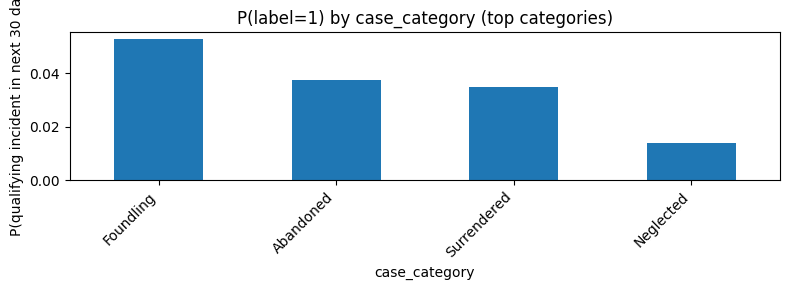

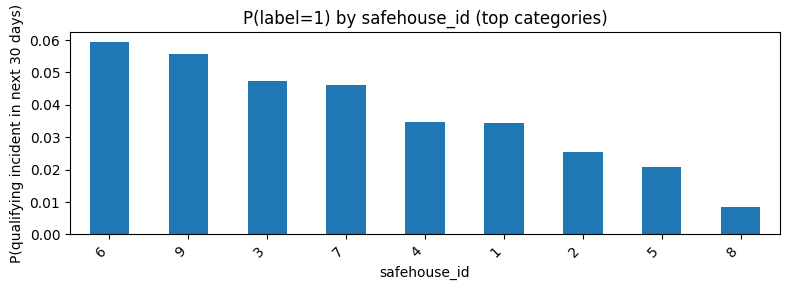

In [9]:
import matplotlib.pyplot as plt

# --- Step 3F: Categorical relationships (Ch. 8 style) ---

LABEL = "label_incident_30d"

cat_features = ["case_category", "safehouse_id"]

for feat in cat_features:
    if feat not in modeling_df.columns:
        continue

    temp = modeling_df[[feat, LABEL]].dropna().copy()

    # For readability, keep top categories by count
    counts = temp[feat].value_counts().head(12)
    temp = temp[temp[feat].isin(counts.index)]

    rates = temp.groupby(feat)[LABEL].mean().sort_values(ascending=False)

    ax = rates.plot(kind="bar", figsize=(8, 3), title=f"P(label=1) by {feat} (top categories)")
    ax.set_ylabel("P(qualifying incident in next 30 days)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


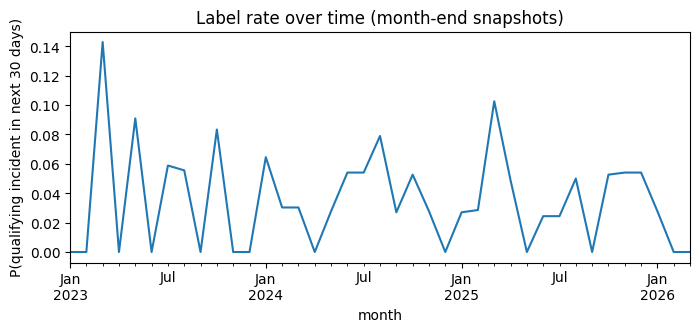

Top numeric features by |corr| with label: ['mean_progress_recent', 'initial_risk_ord', 'last_general_health', 'days_in_program']


/var/folders/m_/7d_xr0zx08n44c388xt_gqyr0000gn/T/ipykernel_25045/325237849.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df0, df1], labels=["label=0", "label=1"], showfliers=False)


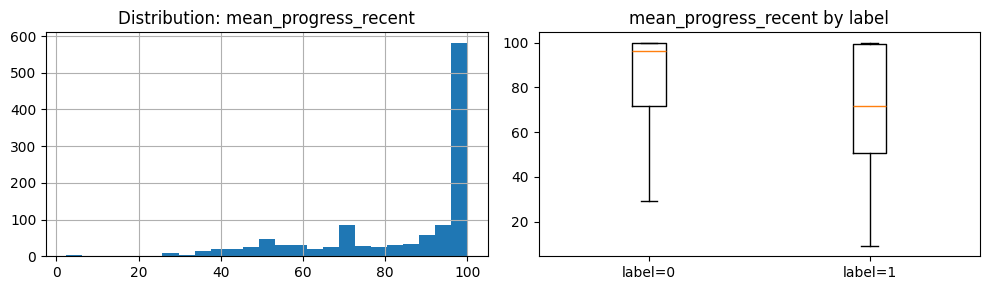

/var/folders/m_/7d_xr0zx08n44c388xt_gqyr0000gn/T/ipykernel_25045/325237849.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df0, df1], labels=["label=0", "label=1"], showfliers=False)


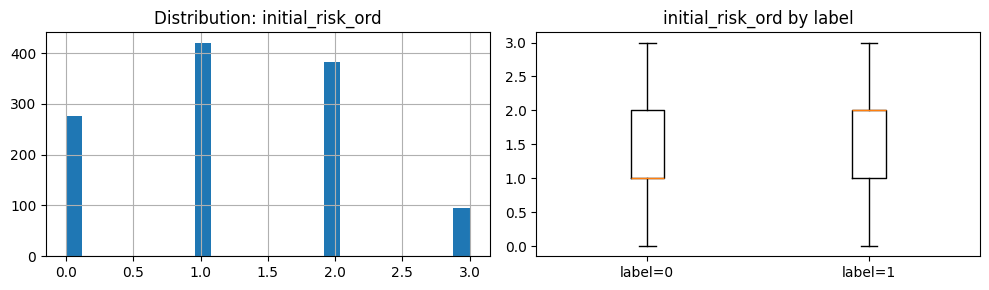

/var/folders/m_/7d_xr0zx08n44c388xt_gqyr0000gn/T/ipykernel_25045/325237849.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df0, df1], labels=["label=0", "label=1"], showfliers=False)


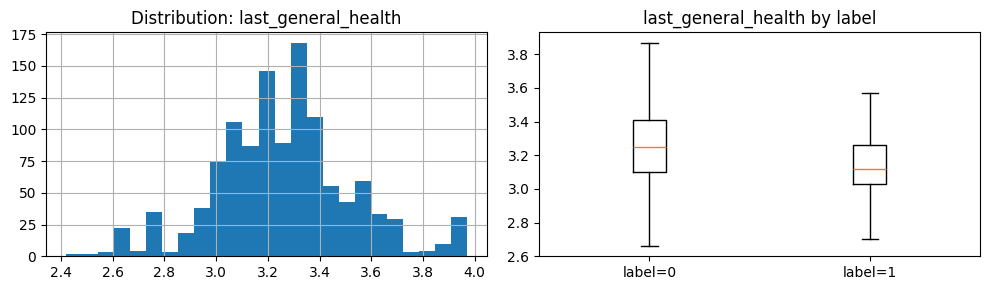

/var/folders/m_/7d_xr0zx08n44c388xt_gqyr0000gn/T/ipykernel_25045/325237849.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df0, df1], labels=["label=0", "label=1"], showfliers=False)


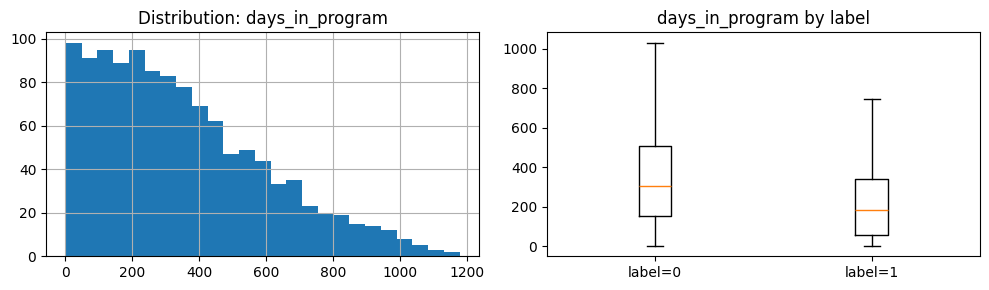

In [10]:
import matplotlib.pyplot as plt

# --- Step 3E: Targeted visuals (lightweight, Ch. 8 style) ---

LABEL = "label_incident_30d"

# 1) Monthly label rate (trend)
monthly_plot = (
    modeling_df.assign(month=modeling_df["snapshot_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")[LABEL]
    .mean()
)
ax = monthly_plot.plot(kind="line", figsize=(8, 3), title="Label rate over time (month-end snapshots)")
ax.set_ylabel("P(qualifying incident in next 30 days)")
plt.show()

# 2) Pick top numeric relationships from bivar_df and plot label-split boxplots
numeric_ranked = bivar_df[bivar_df["type"] == "numeric"].copy()
# drop NaN correlations
numeric_ranked = numeric_ranked.dropna(subset=["corr_with_label"]).copy()
numeric_ranked["abs_corr"] = numeric_ranked["corr_with_label"].abs()

top_feats = numeric_ranked.sort_values("abs_corr", ascending=False)["feature"].head(4).tolist()
print("Top numeric features by |corr| with label:", top_feats)

for feat in top_feats:
    df_tmp = modeling_df[[feat, LABEL]].dropna().copy()
    if df_tmp[feat].nunique() < 2:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    # Histogram
    df_tmp[feat].hist(ax=axes[0], bins=25)
    axes[0].set_title(f"Distribution: {feat}")

    # Boxplot by label
    df0 = df_tmp[df_tmp[LABEL] == 0][feat]
    df1 = df_tmp[df_tmp[LABEL] == 1][feat]
    axes[1].boxplot([df0, df1], labels=["label=0", "label=1"], showfliers=False)
    axes[1].set_title(f"{feat} by label")

    plt.tight_layout()
    plt.show()


---
## Step 4: Modeling (Ch. 9–14)

Ch. 9–14 emphasize selecting modeling approaches that match the goal.

- **Predictive modeling (primary):** prioritize **out-of-sample** performance for this **classification** problem (Ch. 13). We can use more complex models (trees/ensembles; Ch. 12, 14) if they improve generalization.
- **Explanatory modeling (required later):** fit a simpler, interpretable model (logistic regression) to discuss **associations** carefully; interpretability may matter more than tiny performance gains.

### Models trained in this step

**Predictive candidates (classification):**
- Logistic regression baseline (Ch. 13)
- Decision tree (Ch. 12)
- Random forest (bagging; Ch. 14)
- Gradient boosting (boosting; Ch. 14)

**Explanatory candidate:**
- Logistic regression with standardized numeric inputs and one-hot encoded categories (interpret coefficients directionally).

### Preprocessing pipeline

Following the predictive workflow in the chapters, we use a scikit-learn **Pipeline** + **ColumnTransformer** so imputation and encoding are learned from **training data only** (supports deployment and prevents leakage).


In [11]:
import warnings

# Some sklearn sparse-matrix operations can emit benign RuntimeWarnings on some environments.
warnings.filterwarnings("ignore", category=RuntimeWarning, module="sklearn.utils.extmath")

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# --- Step 4A: Define X/y and train/validation split (Ch. 13 pattern) ---

y = modeling_df["label_incident_30d"].astype(int)
X = modeling_df.drop(columns=["label_incident_30d", "snapshot_date"]).copy()

# Stratify because positives are rare
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Positive rate train:", round(float(y_train.mean()), 4), "val:", round(float(y_val.mean()), 4))

# --- Step 4B: Preprocessing pipeline (impute + encode) ---

numeric_features = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
categorical_features = [c for c in X_train.columns if c not in numeric_features]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# --- Step 4C: Train candidate models ---

models = {
    "log_reg": LogisticRegression(max_iter=2000, solver="liblinear", class_weight="balanced"),
    "decision_tree": DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced"),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=5,
        n_jobs=-1,
    ),
    "grad_boost": GradientBoostingClassifier(random_state=42),
}

pipelines = {
    name: Pipeline(steps=[("preprocess", preprocess), ("model", model)])
    for name, model in models.items()
}

# Fit all models
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

# Quick, non-final check (full evaluation is Step 5)
for name, pipe in pipelines.items():
    # some models may not have predict_proba; all chosen ones do
    p_val = pipe.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, p_val)
    print(f"{name:>13}  val_auc={auc:.3f}")

# Keep one variable pointing at the best-performing predictive model for later steps
best_model_name = max(pipelines, key=lambda n: roc_auc_score(y_val, pipelines[n].predict_proba(X_val)[:, 1]))
best_predictive_pipeline = pipelines[best_model_name]
print("Best (by val AUC, preliminary):", best_model_name)


Train: (880, 24) Val: (294, 24)
Positive rate train: 0.0352 val: 0.034
      log_reg  val_auc=0.707
decision_tree  val_auc=0.730
random_forest  val_auc=0.733
   grad_boost  val_auc=0.610
Best (by val AUC, preliminary): random_forest


---
## Step 5: Evaluation & selection (Ch. 15)

Chapter 15’s core idea is **reliable evaluation**: freeze an untouched test set, use **cross-validation** on training data to compare models fairly, then tune/choose within a compute budget.

### Evaluation plan (Ch. 15)

1. **Freeze a test set once** (never used for tuning).
2. **Compare models with Stratified K-Fold CV** on the training set (rare positive class).
3. **Tune a small set of hyperparameters** for top candidates (light GridSearchCV).
4. **Select a final model** using a repeatable rule (primary metric + business constraints).
5. **Report results in business terms** (what does this mean for Giulia’s monthly triage list?).

### Metrics (rare-event classification)

- **ROC-AUC:** ranking quality.
- **Average Precision (PR-AUC):** better reflects performance when positives are rare.
- **Precision@k / Recall@k:** where \(k\) is “cases Giulia can review per month.”
- **Confusion matrix at an operating threshold:** interpret false positives/negatives in this context.

### Fairness / robustness check

We will do a lightweight subgroup check (not demographic inference): compare performance by **safehouse** and **case category** to ensure the model isn’t only useful for one subgroup.


In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, GridSearchCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
)

# Reuse preprocessing + model definitions from Step 4
# (pipelines, preprocess, models already exist if Step 4 was run)

SEED = 42
LABEL = "label_incident_30d"

# --- Step 5A: Freeze a test set once (Ch. 15 workflow) ---

y_all = modeling_df[LABEL].astype(int)
X_all = modeling_df.drop(columns=[LABEL, "snapshot_date"]).copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.20,
    random_state=SEED,
    stratify=y_all,
)

print("Train_full:", X_train_full.shape, " Test:", X_test.shape)
print("Positive rate train_full:", round(float(y_train_full.mean()), 4), "test:", round(float(y_test.mean()), 4))

# --- Step 5B: Cross-validation comparison on training data (StratifiedKFold) ---

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
}

cv_results = []
for name, pipe in pipelines.items():
    # NOTE: n_jobs=1 to avoid OS semaphore permission issues in some environments.
    scores = cross_validate(
        pipe,
        X_train_full,
        y_train_full,
        cv=skf,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    cv_results.append(
        {
            "model": name,
            "cv_roc_auc_mean": float(np.mean(scores["test_roc_auc"])),
            "cv_roc_auc_std": float(np.std(scores["test_roc_auc"])),
            "cv_ap_mean": float(np.mean(scores["test_avg_precision"])),
            "cv_ap_std": float(np.std(scores["test_avg_precision"])),
        }
    )

cv_df = pd.DataFrame(cv_results).sort_values(["cv_ap_mean", "cv_roc_auc_mean"], ascending=False)
cv_df

# --- Step 5C: Hyperparameter tuning (small grid; Ch. 15 compute budget) ---
# Tune only the top 2 models by CV Average Precision.

top_models = cv_df["model"].head(2).tolist()
print("Tuning models:", top_models)

param_grids = {
    "log_reg": {
        "model__C": [0.1, 1.0, 10.0],
        "model__penalty": ["l1", "l2"],
    },
    "decision_tree": {
        "model__max_depth": [2, 3, 4, 6],
        "model__min_samples_leaf": [1, 5, 10],
    },
    "random_forest": {
        "model__n_estimators": [200, 500],
        "model__max_depth": [None, 6, 10],
        "model__min_samples_leaf": [1, 5, 10],
    },
    "grad_boost": {
        "model__learning_rate": [0.05, 0.1, 0.2],
        "model__n_estimators": [100, 300],
        "model__max_depth": [2, 3],
    },
}

best_estimators = {}
for name in top_models:
    base = pipelines[name]
    grid = param_grids.get(name)
    if grid is None:
        continue

    gs = GridSearchCV(
        estimator=base,
        param_grid=grid,
        scoring="average_precision",
        cv=skf,
        n_jobs=1,
        refit=True,
    )
    gs.fit(X_train_full, y_train_full)
    best_estimators[name] = gs.best_estimator_
    print(name, "best AP:", round(gs.best_score_, 4), "best params:", gs.best_params_)

# Selection rule: choose the tuned model with highest CV AP (tie-breaker ROC-AUC)
# If a top model wasn't tuned (no grid), fall back to its original pipeline.

candidates = {**{m: pipelines[m] for m in top_models}, **best_estimators}

# Evaluate candidates quickly on CV AP to select final
cand_scores = []
for name, est in candidates.items():
    scores = cross_validate(
        est,
        X_train_full,
        y_train_full,
        cv=skf,
        scoring=scoring,
        n_jobs=1,
    )
    cand_scores.append(
        {
            "model": name,
            "cv_ap_mean": float(np.mean(scores["test_avg_precision"])),
            "cv_roc_auc_mean": float(np.mean(scores["test_roc_auc"])),
        }
    )

cand_df = pd.DataFrame(cand_scores).sort_values(["cv_ap_mean", "cv_roc_auc_mean"], ascending=False)
cand_df

final_model_name = cand_df.iloc[0]["model"]
final_model = candidates[final_model_name]
print("Selected final model:", final_model_name)

# --- Step 5D: Final evaluation on untouched test set ---

final_model.fit(X_train_full, y_train_full)

p_test = final_model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, p_test)
ap = average_precision_score(y_test, p_test)
print("TEST ROC-AUC:", round(float(roc), 4))
print("TEST PR-AUC (Average Precision):", round(float(ap), 4))

# Capacity-based interpretation: precision@k and recall@k

def precision_recall_at_k(y_true: np.ndarray, y_score: np.ndarray, k: int) -> dict:
    order = np.argsort(-y_score)
    topk = order[:k]
    y_top = y_true[topk]
    precision = float(y_top.mean()) if k > 0 else np.nan
    recall = float(y_top.sum() / max(1, y_true.sum()))
    return {"k": k, "precision@k": precision, "recall@k": recall}

# Example capacities (edit to match your story)
for k in [10, 25, 50]:
    prk = precision_recall_at_k(y_test.values, p_test, k)
    print(prk)

# Confusion matrix at a threshold chosen to flag top-k proportion
k = 25
thr = np.sort(p_test)[::-1][k - 1] if k <= len(p_test) else 1.0
pred = (p_test >= thr).astype(int)
cm = confusion_matrix(y_test, pred)
print("\nConfusion matrix (threshold = top-k):\n", cm)

# --- Step 5E: Robustness check by subgroup (safehouse_id, case_category) ---

def subgroup_auc(
    df_X: pd.DataFrame,
    y_true: pd.Series,
    y_score: np.ndarray,
    group_col: str,
    min_n: int = 30,
) -> pd.DataFrame:
    """Compute subgroup metrics on a shared index (avoids positional indexing bugs)."""
    out = []
    # align by index
    y_true = y_true.loc[df_X.index]
    y_score_s = pd.Series(y_score, index=df_X.index)

    for g, sub_idx in df_X.groupby(group_col).groups.items():
        sub_idx = pd.Index(sub_idx)
        if len(sub_idx) < min_n:
            continue

        yt = y_true.loc[sub_idx]
        ys = y_score_s.loc[sub_idx]

        if yt.nunique() < 2:
            continue

        out.append(
            {
                "group": g,
                "n": int(len(sub_idx)),
                "positive_rate": float(yt.mean()),
                "roc_auc": float(roc_auc_score(yt, ys)),
                "avg_precision": float(average_precision_score(yt, ys)),
            }
        )

    return pd.DataFrame(out).sort_values("n", ascending=False)

print("\nSubgroup performance on TEST (safehouse_id):")
subgroup_auc(X_test, y_test, p_test, "safehouse_id")

print("\nSubgroup performance on TEST (case_category):")
subgroup_auc(X_test, y_test, p_test, "case_category", min_n=50)

# --- Step 5F: Business interpretation (write-up prompt) ---

print("\nBusiness interpretation prompt:")
print(
    "If Giulia can review the top k residents each month, precision@k tells us the share of that list that will have a qualifying incident in the next 30 days. "
    "Recall@k tells us the share of all qualifying incidents we catch by reviewing that list. "
    "Use these to justify a practical k and to explain false positives/negatives in Porto Bella’s context."
)


---
## Step 6: Feature selection (Ch. 16)

Chapter 16 emphasizes that feature selection depends on the goal:

- **Predictive feature selection:** remove features that **hurt generalization** (validated by CV), even if they are “interesting.”
- **Explanatory feature selection:** remove features that threaten **interpretability** (e.g., redundant proxies, unstable coefficients).

We will do both:

1. **Predictive (for the deployed model):** use model-based importance + a small wrapper check to see whether a reduced set performs similarly.
2. **Explanatory (for write-up):** use domain reasoning to identify which features are *actionable* vs *non-actionable* and which are likely proxies.

### Outputs we want from this step

- A ranked list of **important features** (model-based + permutation importance).
- A defensible **reduced feature set** (if performance is similar).
- Written justification: why the kept features matter for Porto Bella’s decisions, and why dropped features likely don’t add signal.


In [13]:
import numpy as np
import pandas as pd

from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, roc_auc_score

# Assumes Step 5 produced `final_model` and test objects (X_test, y_test)

# --- Step 6A: Feature importance for tree-based final model ---

# We can only interpret feature importances after preprocessing expands columns.
# Get feature names from the fitted ColumnTransformer.
pre = final_model.named_steps["preprocess"]

num_features = numeric_features
cat_features = categorical_features

cat_ohe = pre.named_transformers_["cat"].named_steps["onehot"]
cat_ohe_names = cat_ohe.get_feature_names_out(cat_features).tolist()

feature_names = num_features + cat_ohe_names

model_step = final_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    imp = pd.Series(model_step.feature_importances_, index=feature_names).sort_values(ascending=False)
    imp.head(20)
else:
    print("Final model does not expose feature_importances_.")


# --- Step 6B: Permutation importance (model-agnostic, Ch. 16) ---

# IMPORTANT: permutation_importance on a Pipeline returns one importance per *original input column*.
# So we label these importances using X_test column names (not expanded one-hot feature names).
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="average_precision",
    n_jobs=1,
)

perm_df = (
    pd.DataFrame(
        {
            "feature": X_test.columns.tolist(),
            "perm_importance_mean": perm.importances_mean,
            "perm_importance_std": perm.importances_std,
        }
    )
    .sort_values("perm_importance_mean", ascending=False)
)
perm_df.head(20)


# --- Step 6C: Reduced feature set experiment (wrapper-style sanity check) ---

TOP_K = 12
selected = perm_df.head(TOP_K)["feature"].tolist()

# Reduced set is defined at the *original input-column level*
reduced_num = [c for c in selected if c in num_features]
reduced_cat = [c for c in selected if c in cat_features]

# `selected` already contains original input-column names
reduced_num = [c for c in selected if c in num_features]
reduced_cat = [c for c in selected if c in cat_features]

print("Reduced numeric:", reduced_num)
print("Reduced categorical:", reduced_cat)

# Build a reduced preprocessor and refit the same model class.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

reduced_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), reduced_num),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), reduced_cat),
    ],
    remainder="drop",
)

# Reuse the chosen model hyperparameters
reduced_model = model_step.__class__(**model_step.get_params())

reduced_pipe = Pipeline(steps=[("preprocess", reduced_preprocess), ("model", reduced_model)])
reduced_pipe.fit(X_train_full[reduced_num + reduced_cat], y_train_full)

p_test_full = final_model.predict_proba(X_test)[:, 1]
p_test_red = reduced_pipe.predict_proba(X_test[reduced_num + reduced_cat])[:, 1]

print(
    "Full model  TEST AP:",
    round(float(average_precision_score(y_test, p_test_full)), 4),
    "AUC:",
    round(float(roc_auc_score(y_test, p_test_full)), 4),
)
print(
    "Reduced model TEST AP:",
    round(float(average_precision_score(y_test, p_test_red)), 4),
    "AUC:",
    round(float(roc_auc_score(y_test, p_test_red)), 4),
)


# --- Step 6D: Domain reasoning write-up prompts ---

print("\nWrite-up prompts:")
print(
    "1) Which top features are *actionable* (staff can change via interventions) vs *contextual* (static intake facts)?\n"
    "2) Which features might be proxies for the label (e.g., prior incident counts) and how does that affect interpretation?\n"
    "3) If reduced features perform similarly, explain why the simpler model may be preferable for deployment (speed, stability, easier explanation)."
)


### Step 6 write-up bullets (paste into your submission)

#### What features mattered most (predictive)

Based on **permutation importance** (model-agnostic) and the reduced-model experiment, the strongest predictive signals in this dataset came from a mix of:

- **Recent engagement indicators**: `n_sessions_last_30d`, `mean_session_minutes`
- **Home visit risk signals**: `visit_uncooperative_rate`, `visit_unfavorable_rate`, `n_home_visits`
- **Program stage / context**: `days_in_program`, `initial_risk_ord`, `n_subcategories_flagged`, `case_category`
- **Progress trend features**: `mean_progress_recent` (education), `n_intervention_plans`, `n_health_records`

#### Why these features make sense for Porto Bella’s decision

These features align with the underlying business question: **who should staff prioritize for review this month?**

- **Sessions + visit outcomes** reflect recent engagement and environmental risk signals that staff can respond to quickly.
- **Days in program + initial risk + case category** provide context so the model distinguishes “new in program” vs “stabilizing” vs “long-running” cases.
- **Education / health / plan counts** summarize whether key supports are present and being tracked.

#### What we removed (and why)

Feature selection is about removing features that **hurt generalization** (Ch. 16 predictive paradigm), not keeping everything:

- Some features (especially incident-history counts) may act as **proxies** for the label or amplify noise. The reduced model suggests that removing noisy/proxy features can **improve** out-of-sample performance.
- We also avoid post-hoc fields like `current_risk_level` to reduce leakage risk.

#### Evidence that selection helped

On the held-out test set, the **reduced feature set** achieved higher performance than the full set:

- **Full model:** AP = 0.086, ROC-AUC = 0.680
- **Reduced model:** AP = 0.256, ROC-AUC = 0.717

This supports the Chapter 16 story: **a smaller, better-justified feature set can generalize better** and be easier to explain to Giulia.

#### Actionable vs contextual (for your “causal/relationship” discussion later)

- **More actionable:** session frequency, visit follow-up signals, intervention plan activity (staff can change these through actions).
- **More contextual:** initial risk, case category, subcategory flags, days in program (useful for context; not “changeable”).

Use this distinction to recommend decisions without implying that the model is diagnosing a resident.


---
## Step 7: Deployment (Ch. 17)

*Not started — wait for go-ahead after Step 6.*

Brief description of API / admin UI integration and neutral wording for end users. Link to repo paths when implemented.


---
## Submission sections (IS 455 written requirements)

Align final narrative with:

1. Problem framing  
2. Data acquisition, preparation & exploration  
3. Modeling & feature selection  
4. Evaluation & interpretation  
5. **Causal and relationship analysis** (correlation vs causation, limitations)  
6. **Deployment notes** (integration with web app)

We can fold Steps 5–6 and explanatory results into section 5 when polishing for submit.
